# Plot

In [1]:
import os
import pickle
from pathlib import Path

import matplotlib as mpl
import matplotlib.cm as cm
import matplotlib.pyplot as plt
import numpy as np
from scipy.optimize import brentq
from sklearn.manifold import TSNE

mpl.rcParams.update({
    "pdf.fonttype": 42,            # editable text in Adobe Illustrator
    "ps.fonttype": 42,             # editable text in Adobe Illustrator

    "figure.dpi": 200,
    "savefig.dpi": 600,              # very high-res when saving
    "savefig.format": "pdf",         # vector output preferred

    # # Fonts
    "font.family": "serif",
    # "font.serif": ["Times New Roman"],  # IEEE default

    # font size
    "axes.titlesize": 14,      # subplot title
    "axes.labelsize": 14,      # x/y axis labels
    "xtick.labelsize": 12,     # x tick labels
    "ytick.labelsize": 12,     # y tick labels
    "legend.fontsize": 10,     # legend text
    "figure.titlesize": 14,    # fig.suptitle

    # # Axes
    "axes.linewidth": 1.0,
    # Lines
    "lines.linewidth": 1.5,
})

# plt.rcParams['text.usetex'] = True
plt.rcParams['font.family'] = 'serif'


# # vanilla PPO
# DATA_ROOT = Path(os.path.realpath('__file__')).parent.parent.parent.parent / "logs" / "rsl_rl/g1_29dof_soft_vanilla_ppo"
# data_dir = DATA_ROOT / "2026-04-10_18-17-46" / "logs"

# # vae teacher
# DATA_ROOT = Path(os.path.realpath('__file__')).parent.parent.parent.parent / "logs" / "rsl_rl/g1_29dof_soft_vae_teacher"
# # data_dir = DATA_ROOT / "2026-04-16_22-19-54" / "logs"
# # data_dir = DATA_ROOT / "2026-04-24_02-54-25" / "logs"
# # data_dir = DATA_ROOT / "2026-04-25_02-51-12" / "logs"
# # data_dir = DATA_ROOT / "2026-04-29_21-48-32" / "logs"
# data_dir = DATA_ROOT / "2026-05-02_11-26-49" / "logs"

# # vae RNN student
# DATA_ROOT = Path(os.path.realpath('__file__')).parent.parent.parent.parent / "logs" / "rsl_rl/g1_29dof_soft_vae_student"
# # data_dir = DATA_ROOT / "2026-04-16_22-19-54" / "logs"
# data_dir = DATA_ROOT / "2026-04-17_18-56-22" / "logs"

# # vae TCN student (distillation only)
# DATA_ROOT = Path(os.path.realpath('__file__')).parent.parent.parent.parent / "logs" / "rsl_rl/g1_29dof_soft_vae_student_tcn"
# data_dir = DATA_ROOT / "2026-04-21_22-36-08" / "logs"

# vae TCN student (distillation + PPO)
DATA_ROOT = Path(os.path.realpath('__file__')).parent.parent.parent.parent / "logs" / "rsl_rl/g1_29dof_soft_vae_student_tcn"
# data_dir = DATA_ROOT / "2026-04-23_00-44-01" / "logs"
# data_dir = DATA_ROOT / "2026-04-26_18-30-36" / "logs"
# data_dir = DATA_ROOT / "2026-04-28_14-34-52" / "logs"

# data_dir = DATA_ROOT / "2026-04-28_21-07-48" / "logs"
# data_dir = DATA_ROOT / "2026-04-29_21-39-36" / "logs"
# data_dir = DATA_ROOT / "2026-05-02_00-13-44" / "logs"

# data_dir = DATA_ROOT / "2026-05-03_17-44-18" / "logs"
# data_dir = DATA_ROOT / "2026-05-04_00-55-10" / "logs"
data_dir = DATA_ROOT / "2026-05-04_20-27-55" / "logs"

In [2]:
def quat_to_yaw(quat):
    """Extract yaw from quaternion [w, x, y, z]"""
    w, x, y, z = quat[..., 0], quat[..., 1], quat[..., 2], quat[..., 3]
    yaw = np.arctan2(2.0*(w*z + x*y), 1.0 - 2.0*(y*y + z*z))
    return yaw

In [3]:
base_pos = slice(0, 3)
yaw_quat_idx = slice(3, 7)  # w, x, y, z
base_lin_vel_idx = slice(7, 10)   # x, y, z
base_ang_vel_idx = slice(10, 13)   # roll, pitch, yaw
velocity_commands_idx = slice(13, 16)  # x, y, yaw
heading_commands_idx = slice(16, 20)
grf_idx = slice(20, 26)


# privileged
priv_base_lin_vel_idx = slice(0, 3)
foot_height_idx = slice(3, 5)

rigid_contact_idx = slice(5, 7)
rigid_contact_force_idx = slice(7, 13)
rigid_air_time_idx = slice(13, 15)

soft_contact_idx = slice(15, 17)
soft_contact_force_idx = slice(17, 23)
soft_air_time_idx = slice(23, 25)

material_idx = slice(25, 28)

# log privileged
contact_idx = slice(5, 7)
contact_force_idx = slice(7, 13)
foot_air_time_idx = slice(13, 15)
material_prop_idx = slice(15, None)

In [12]:
# data_path = data_dir / "rl_play"
# data_path = data_dir / "rigid"
# data_path = data_dir / "static"
# data_path = data_dir / "rigid_with_soft"
# data_path = data_dir / "terrain_transition"
# data_path = data_dir / "terrain_transition_soft"
# data_path = data_dir / "terrain_transition_soft_undertrain"
# data_path = data_dir / "terrain_transition_soft_2"
# data_path = data_dir / "terrain_transition_soft_undertrain"

# data_path = data_dir / "2d_rft"
# data_path = data_dir / "3d_rft"
data_path = data_dir / "2d_rft_non_filter"
# data_path = data_dir / "3d_rft_non_filter"

policy_obs_path = (data_path / "obs/obs.pkl").as_posix()
privileged_obs_path = (data_path / "privileged/privileged.pkl").as_posix()
latent_path = (data_path / "latent/latent.pkl").as_posix()
decoder_path = (data_path / "decoder_output/decoder_output.pkl").as_posix()

with open(policy_obs_path, "rb") as f:
    policy_obs = pickle.load(f)
    policy_obs = np.array(policy_obs).squeeze(1)

with open(privileged_obs_path, "rb") as f:
    privileged_obs = pickle.load(f)
    privileged_obs = np.array(privileged_obs).squeeze(1)

with open(latent_path, "rb") as f:
    latent = pickle.load(f)
    latent = np.array(latent).squeeze(1)

with open(decoder_path, "rb") as f:
    decoder_output = pickle.load(f)
    decoder_output = np.array(decoder_output).squeeze(1)

print(f"policy_obs shape: {policy_obs.shape}")
print(f"privileged obs shape: {privileged_obs.shape}")
print(f"latent shape: {latent.shape}")
print(f"decoder shape: {decoder_output.shape}")

data = {}
data["yaw_quat"] = policy_obs[:, :, yaw_quat_idx]
data["base_lin_vel"] = policy_obs[:, :, base_lin_vel_idx]
data["base_ang_vel"] = policy_obs[:, :, base_ang_vel_idx]
data["velocity_commands"] = policy_obs[:, :, velocity_commands_idx]
data["heading_commands"] = policy_obs[:, :, heading_commands_idx]
data["GRF"] = policy_obs[:, :, grf_idx]

privileged_data = {}
privileged_data["base_lin_vel"] = privileged_obs[:, :, priv_base_lin_vel_idx]
privileged_data["foot_height"] = privileged_obs[:, :, foot_height_idx]
privileged_data["contact"] = privileged_obs[:, :, contact_idx]
privileged_data["contact_force"] = privileged_obs[:, :, contact_force_idx]
privileged_data["foot_air_time"] = privileged_obs[:, :, foot_air_time_idx]
privileged_data["material_prop"] = privileged_obs[:, :, material_prop_idx]

decoded_privileged_data = {}
decoded_privileged_data["material_prop"] = decoder_output

policy_obs shape: (1, 600, 26)
privileged obs shape: (1, 600, 16)
latent shape: (1, 600, 64)
decoder shape: (1, 600, 1)


In [13]:
ENV_ID = 0
policy_hz = 50
dt = 1/policy_hz
T_terminal = dt * policy_obs.shape[1]
t = np.linspace(0, T_terminal, int(T_terminal * policy_hz))
t_range = slice(5, int(T_terminal * policy_hz))
t_plot = t[t_range]

### Plot

### GRF plot

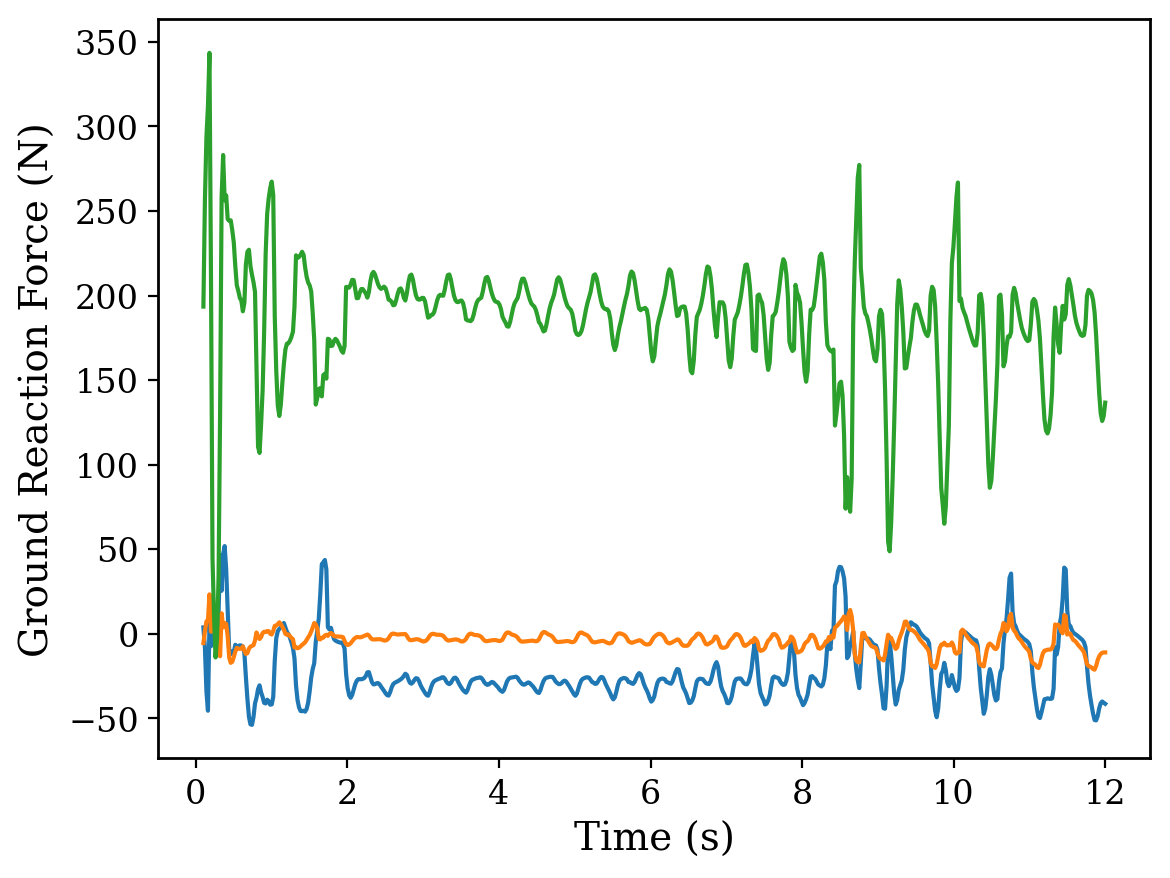

In [14]:
env_id = 0 
plt.plot(t_plot, data["GRF"][env_id, t_range, 0], label="L_x")
plt.plot(t_plot, data["GRF"][env_id, t_range, 1], label="L_y")
plt.plot(t_plot, data["GRF"][env_id, t_range, 2], label="L_z")

plt.xlabel("Time (s)")
plt.ylabel("Ground Reaction Force (N)")

plt.savefig("2d_rft_left_grf.pdf")
# plt.savefig("3d_rft_left_grf.pdf")
plt.show()

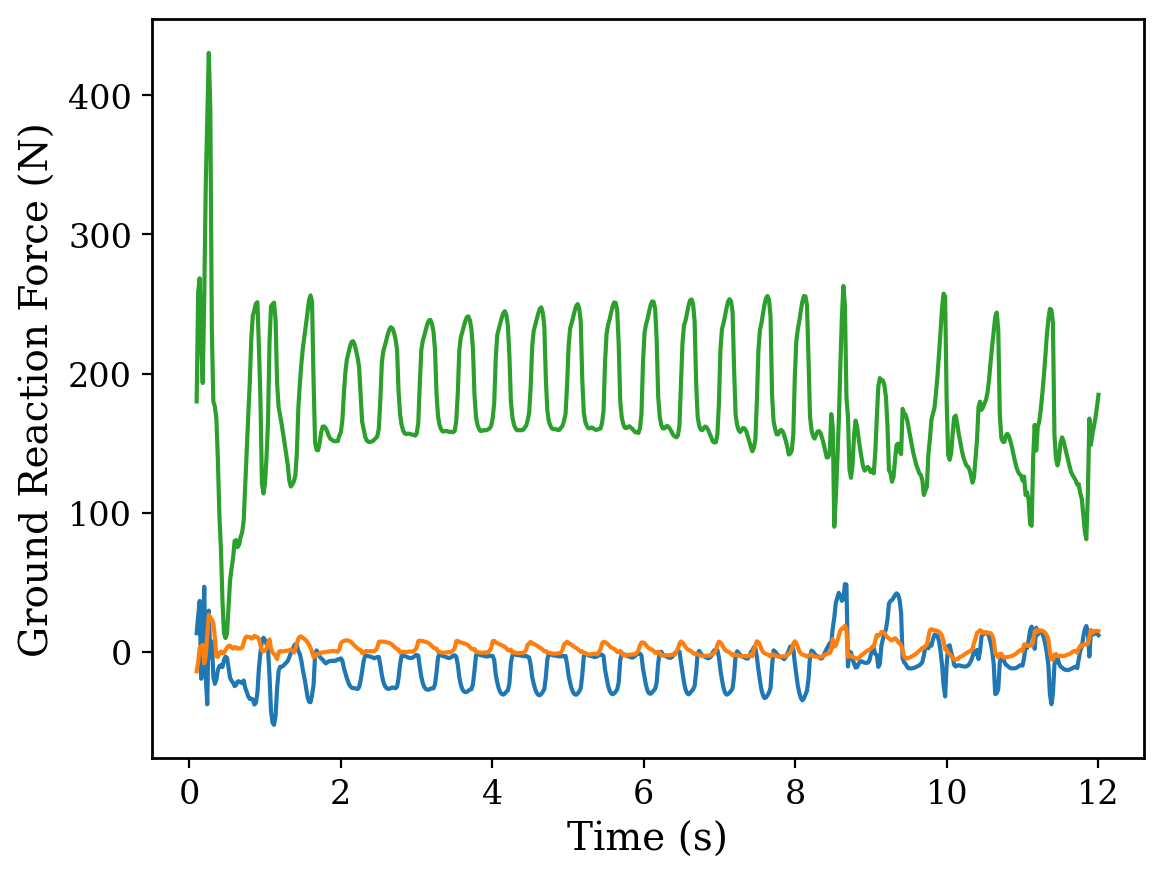

In [15]:
env_id = 0 
plt.plot(t_plot, data["GRF"][env_id, t_range, 3], label="R_x")
plt.plot(t_plot, data["GRF"][env_id, t_range, 4], label="R_y")
plt.plot(t_plot, data["GRF"][env_id, t_range, 5], label="R_z")

plt.xlabel("Time (s)")
plt.ylabel("Ground Reaction Force (N)")

plt.savefig("2d_rft_right_grf.pdf")
# plt.savefig("3d_rft_right_grf.pdf")
plt.show()

### privileged info plot

#### ground truth

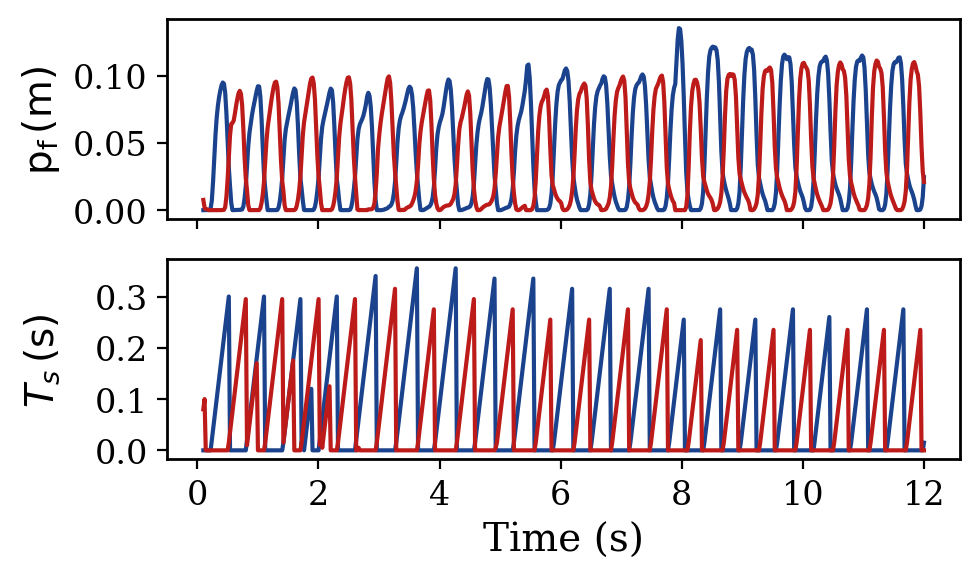

In [5]:
ENV_ID = 0
policy_hz = 50
dt = 1/policy_hz
T_terminal = dt * policy_obs.shape[1]
t = np.linspace(0, T_terminal, int(T_terminal * policy_hz))
t_range = slice(5, int(T_terminal * policy_hz))
t_plot = t[t_range]

colors_left  = ["#1B438D", "#4A87F8"]
colors_right = ["#BD1A1A", "#F87F7F"]

def foot_force_norm(force_flat):
    return np.linalg.norm(force_flat.reshape(force_flat.shape[0], 2, 3), axis=-1)

foot_height         = privileged_data["foot_height"][ENV_ID, t_range]
contact       = privileged_data["contact"][ENV_ID, t_range]
# force_norm    = foot_force_norm(log_privileged_data["contact_force"][ENV_ID, t_range])
contact_force    = privileged_data["contact_force"][ENV_ID, t_range][:, [2, 5]]
contact_force = np.expm1(contact_force)

foot_air_time      = privileged_data["foot_air_time"][ENV_ID, t_range]
material_prop = privileged_data["material_prop"][ENV_ID, t_range]

# get foot clearance
dt = 0.02
win = max(1, int(0.2 / dt))
foot_min = foot_height.min(axis=1)  # min across both feet at each step
ground_level = np.array([foot_min[max(0, i - win):i + 1].min() for i in range(len(foot_min))])
foot_clearance = foot_height - ground_level[:, None]


fig, axs = plt.subplots(2, 1, figsize=(5, 3), sharex=True)

# ── 0: foot height ───────────────────────────────────────────────────────────
ax = axs[0]
# ax.plot(t_plot, foot_height[:, 0], label="left",  color=colors_left[0])
# ax.plot(t_plot, foot_height[:, 1], label="right", color=colors_right[0])
ax.plot(t_plot, foot_clearance[:, 0], label="left",  color=colors_left[0])
ax.plot(t_plot, foot_clearance[:, 1], label="right", color=colors_right[0])
ax.set_ylabel(r"$\mathrm{p_f} \, \mathrm{(m)}$")
# ax.yaxis.set_major_locator(plt.MaxNLocator(5))
# ax.set_ylim(-0.15, 0.15)
# ax.legend(frameon=True)
# ax.grid(True, linestyle='--', linewidth=0.5, alpha=0.7)

# ── 1: air time ────────────────────────────────────────────────────────
ax = axs[1]
ax.plot(t_plot, foot_air_time[:, 0], label="left",  color=colors_left[0])
ax.plot(t_plot, foot_air_time[:, 1], label="right", color=colors_right[0])
ax.set_ylabel(r"$T_s \, \mathrm{(s)}$")
# ax.yaxis.set_major_locator(plt.MaxNLocator(5))
# ax.legend(loc="upper right")
ax.yaxis.set_major_locator(plt.MaxNLocator(4))
# ax.grid(True, linestyle='--', linewidth=0.5, alpha=0.7)

# # ── 2: norm of contact force ───────────────────────────────────────────
# ax = axs[2]
# ax.plot(t_plot, contact_force[:, 0], label="left",  color=colors_left[0])
# ax.plot(t_plot, contact_force[:, 1], label="right", color=colors_right[0])
# ax.set_ylabel(r"$\mathrm{F_z} \, \mathrm{(N)}$")
# # ax.set_ylim(0, 800)
# # ax.yaxis.set_major_locator(plt.MaxNLocator(5))
# # ax.legend(loc="upper right")
# ax.grid(True, linestyle='--', linewidth=0.5, alpha=0.7)

# # ── 3: contact ─────────────────────────────────────────────────────────
# ax = axs[3]
# ax.plot(t_plot, contact[:, 0], label="left",  color=colors_left[0])
# ax.plot(t_plot, contact[:, 1], label="right", color=colors_right[0])
# ax.set_ylabel(r"$\mathrm{c_f}$")
# ax.set_yticks([0, 1])
# # ax.legend(loc="upper right")
# ax.grid(True, linestyle='--', linewidth=0.5, alpha=0.7)


# ax = axs[3]
# ax.plot(t_plot, material_prop[:, 0], label="friction",  color=colors_right[0])
# ax.plot(t_plot, material_prop[:, 1], label="stiffness",  color=colors_left[0])
# # ax.plot(t_plot, material_prop[:, 2], label=r"$\mu_\text{int}$", color=colors_right[0])
# ax.set_ylabel("Material")
# ax.yaxis.set_major_locator(plt.MaxNLocator(5))
# ax.legend()
# ax.grid(True, linestyle='--', linewidth=0.5, alpha=0.7)


ax.set_xlabel("Time (s)")
fig.align_ylabels(axs)
plt.tight_layout()
plt.savefig(os.path.join(data_path, "state.pdf"))
plt.show()

#### terrain reconstruction

In [6]:
def mu_int_from_stiffness_batch(stiffness_arr, rho_arr, mu_rigid=0.9, rho_max=3000.0):                                                                                                  
      def poly(mu):                                                                                                                                                                       
          return 894.0 * mu**3 - 386.0 * mu**2 + 89.0 * mu                                                                                                                                                                                                                                                                        
      C = poly(mu_rigid)                                                                                                                                                                  
      rho_arr = np.broadcast_to(np.asarray(rho_arr, dtype=float), stiffness_arr.shape)                                                                                                    
      results = np.empty_like(stiffness_arr, dtype=float)                                                                                                                                 
      for i, (s, rho) in enumerate(zip(stiffness_arr.flat, rho_arr.flat)):                                                                                                                
          target = np.clip(s * rho_max * C / rho, 0.0, C)                                                                                                                                 
          results.flat[i] = brentq(lambda mu: poly(mu) - target, 0.0, mu_rigid + 1e-9)                                                                                                    
      return results

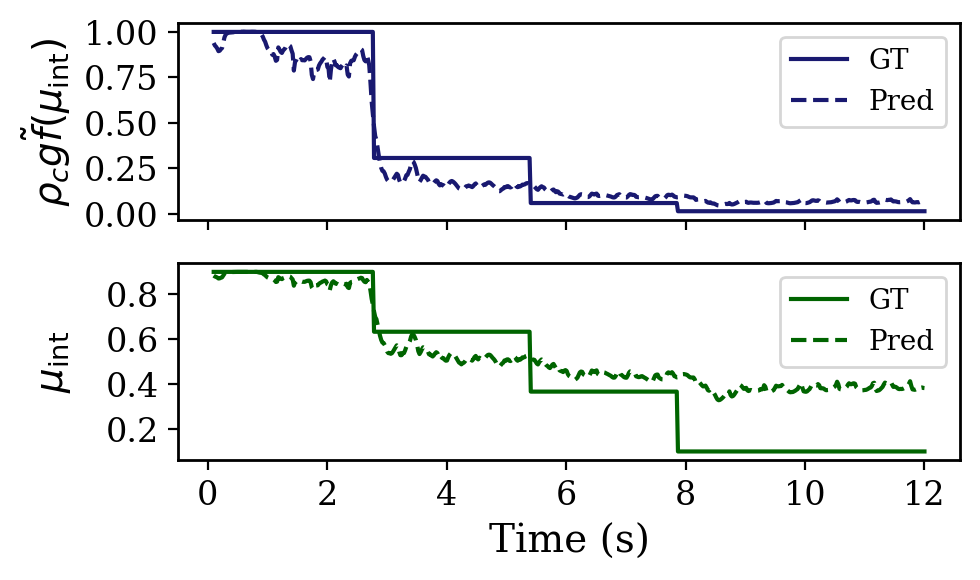

In [7]:
material_prop_recon = decoded_privileged_data["material_prop"][ENV_ID, t_range]


fig, axs = plt.subplots(2, 1, figsize=(5, 3), sharex=True)

colors  = ["midnightblue", "darkgreen"]


idx = 0
# idx = 1
stiffness_gt = material_prop[:, idx]
stiffness_pred = material_prop_recon[:, idx]

rho = 3000 * np.ones_like(stiffness_gt)
true_mu = np.tan(np.pi / 6) * np.ones_like(stiffness_gt)

# stiffness
ax = axs[0]
ax.plot(t_plot, stiffness_gt, label="GT", color=colors[0])
ax.plot(t_plot, stiffness_pred, label="Pred", color=colors[0], linestyle="--")
ax.set_ylabel(r"$\rho_c g \tilde{f}(\mu_\text{int})$")
ax.legend()
ax.yaxis.set_major_locator(plt.MaxNLocator(5))
# ax.grid(True, linestyle='--', linewidth=0.5, alpha=0.7)


# mu_int
ax = axs[1]
mu_int_gt = mu_int_from_stiffness_batch(stiffness_gt, rho)
mu_int_pred = mu_int_from_stiffness_batch(stiffness_pred, rho)

ax.plot(t_plot, mu_int_gt, label="GT", color=colors[1])
ax.plot(t_plot, mu_int_pred, label="Pred", color=colors[1], linestyle="--")
ax.set_ylabel(r"$\mu_\text{int}$")
ax.legend()
ax.yaxis.set_major_locator(plt.MaxNLocator(5))
# ax.grid(True, linestyle='--', linewidth=0.5, alpha=0.7)

ax.set_xlabel("Time (s)")
fig.align_ylabels(axs)

plt.tight_layout()
plt.savefig(os.path.join(data_path, "decoded_state.pdf"))
plt.show()

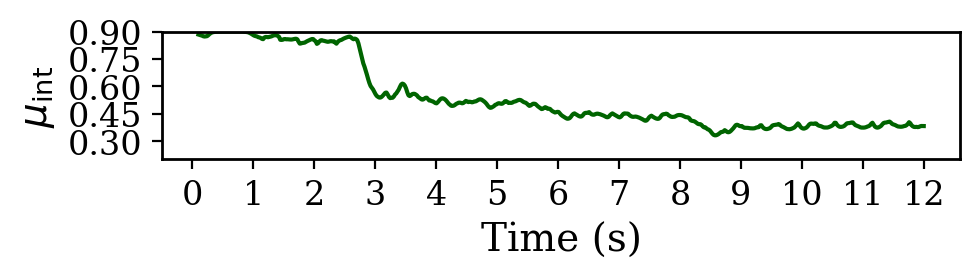

In [8]:
idx = 0
# idx = 1
stiffness = material_prop_recon[:, idx]
rho = 3000 * np.ones_like(stiffness_gt)

mu_int_pred = mu_int_from_stiffness_batch(stiffness, rho)
stiffness_filt = np.zeros_like(stiffness)
mu_int_pred_filt = np.zeros_like(mu_int_pred)


# filtering
# exponential filtering
alpha = .5
stiffness_filt[0] = stiffness[0]
mu_int_pred_filt[0] = mu_int_pred[0]
for i in range(1, len(stiffness)):
    stiffness_filt[i] = alpha * stiffness[i] + (1 - alpha) * stiffness_filt[i-1]
    mu_int_pred_filt[i] = alpha * mu_int_pred[i] + (1 - alpha) * mu_int_pred_filt[i-1]

# fig, axs = plt.subplots(2, 1, figsize=(5, 3), sharex=True)
fig, ax = plt.subplots(1, 1, figsize=(5, 1.5), sharex=True)
colors  = ["midnightblue", "darkgreen"]

# # stiffness
# ax = axs[0]
# # ax.plot(time, stiffness, color=colors[0])
# ax.plot(time, stiffness_filt, color=colors[0])
# ax.set_ylabel(r"$\rho_c g \tilde{f}(\mu_\text{int})$")
# # ax.legend()
# ax.yaxis.set_major_locator(plt.MaxNLocator(5))
# # ax.grid(True, linestyle='--', linewidth=0.5, alpha=0.7)

# mu_int
# ax = axs[1]
# ax.plot(time, mu_int_pred, color=colors[1])
ax.plot(t_plot, mu_int_pred_filt, color=colors[1])
# ax.plot(t_plot, mu_int_pred, color=colors[1], alpha=0.2)
ax.set_ylabel(r"$\mu_\text{int}$")
# ax.legend()
ax.set_ylim(0.2, .9)
ax.xaxis.set_major_locator(plt.MultipleLocator(1))
ax.yaxis.set_major_locator(plt.MaxNLocator(5))
# ax.grid(True, linestyle='--', linewidth=0.5, alpha=0.7)

ax.set_xlabel("Time (s)")
# fig.align_ylabels(ax)
plt.tight_layout()
# plt.savefig(os.path.join(data_path, "decoded_state.pdf"))
plt.show()

### latent visualization

#### T-SNE

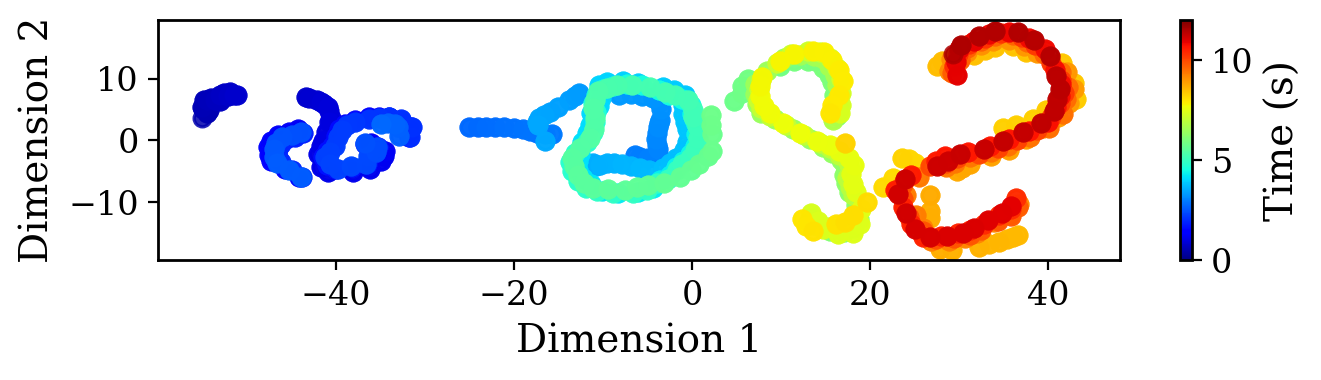

In [9]:
ENV_ID = 0
latent_z = latent[ENV_ID]

# ── t-SNE: collapse (seq_len, latent_dim) → (seq_len, 2) ─────
tsne = TSNE(
    n_components=2,
    perplexity=min(30, len(latent_z) - 1),
    max_iter=1000,
    random_state=42,
)
z_2d = tsne.fit_transform(latent_z)   # (seq_len, 2)

# ── EMA smoothing ──────────────────────────────────────────────
alpha = 1  # smaller = smoother
z_smooth = np.zeros_like(z_2d)
z_smooth[0] = z_2d[0]
for i in range(1, len(z_2d)):
    z_smooth[i] = alpha * z_2d[i] + (1 - alpha) * z_smooth[i - 1]

# ── phase portrait ─────────────────────────────────────────────
# seq_len = len(z_2d)
# t = np.arange(seq_len)                # time index for coloring
cmap = "jet"

fig, ax = plt.subplots(figsize=(7, 2))

# draw trajectory segments colored by time
for i in range(int(0.5/dt), len(z_2d) - int(0.5/dt)):
    color = cm.jet(t[i] / T_terminal)
    ax.scatter(z_smooth[i:i+2, 0], z_smooth[i:i+2, 1], color=color, lw=1.2, alpha=0.85)

sm = plt.cm.ScalarMappable(cmap=cmap, norm=plt.Normalize(0, T_terminal))
sm.set_array([])
plt.colorbar(sm, ax=ax, label="Time (s)")

ax.set_xlabel("Dimension 1")
ax.set_ylabel("Dimension 2")
# ax.set_title(f"Latent Phase Portrait (t-SNE)")
# ax.legend(loc="upper right")
plt.tight_layout()
# plt.axis("equal")

# flip sign of tick labels
# ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f"{-x:g}"))
# ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f"{-y:g}"))

# plt.savefig(os.path.join(data_path, "tsne_scatter.pdf"))
plt.show()

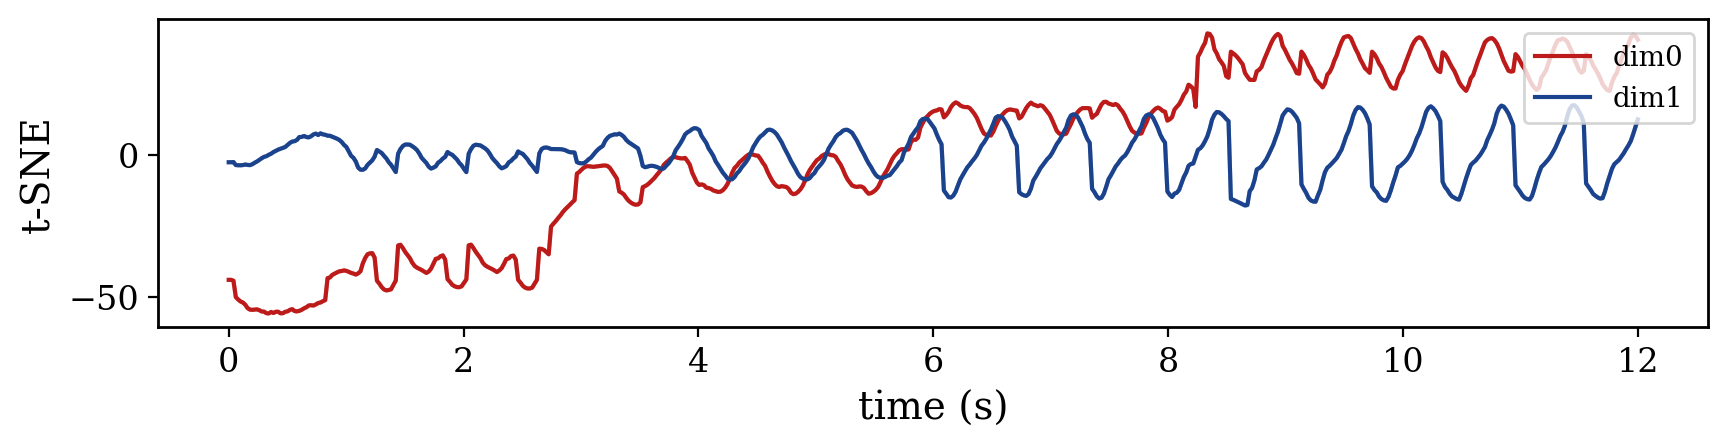

In [10]:
ENV_ID = 0
latent_z = latent[ENV_ID]
# mu = latent_z.mean(axis=0, keepdims=True)          # (1, latent_dim)
# std = latent_z.std(axis=0, keepdims=True) + 1e-8   # avoid div-by-zero
# latent_z = (latent_z - mu) / std
dt = 0.02  # seconds per step (sim.dt=0.005 * decimation=4)
colors  = ["#BD1A1A", "#1B438D"]


fig, ax = plt.subplots(1, 1, figsize=(10, 2), sharex=True)

ax.plot(t, z_2d[:, 0], color=colors[0], alpha=0.3)
ax.plot(t, z_2d[:, 1], color=colors[1], alpha=0.3)

ax.plot(t, z_smooth[:, 0], color=colors[0], label="dim0")
ax.plot(t, z_smooth[:, 1], color=colors[1], label="dim1")

ax.set_xlabel("time (s)")
ax.set_ylabel("t-SNE")
# ax.grid(True, linestyle='--', linewidth=0.5, alpha=0.7)
ax.legend(loc="upper right")

# fig.suptitle(f"Latent t-SNE Dimensions")
plt.savefig(os.path.join(data_path, "tsne.pdf"))
plt.show()

#### Heatmap

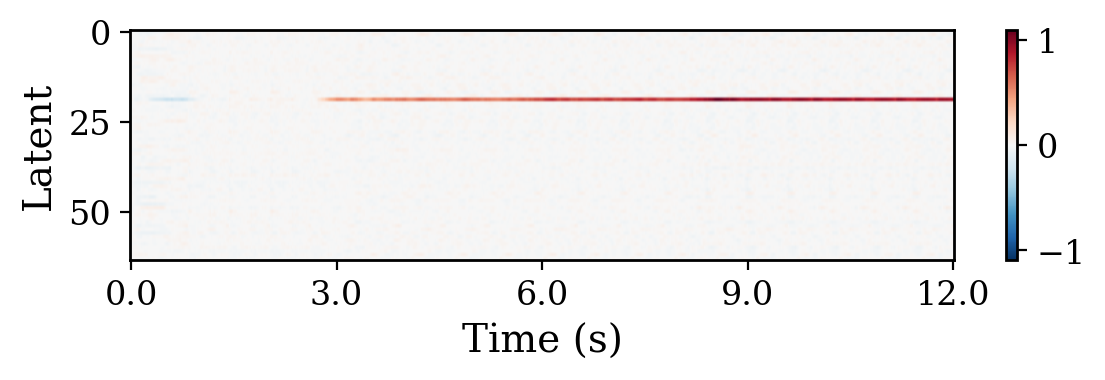

In [11]:
import matplotlib.colors as mcolors

ENV_ID = 0
latent_z = latent[ENV_ID]
latent_z = latent_z.transpose(1, 0)   # (latent_dim, seq_len)

seq_len = latent_z.shape[1]

# Center colormap at 0: white=0, red=positive, blue=negative
vmax = np.abs(latent_z).max()
vmin = -vmax
norm = mcolors.TwoSlopeNorm(vmin=vmin, vcenter=0, vmax=vmax)

fig, ax = plt.subplots(figsize=(6, 2))
im = ax.imshow(latent_z, aspect="auto", cmap="RdBu_r", norm=norm)
fig.colorbar(im, ax=ax)

# map pixel indices → time in seconds
n_ticks = 5
tick_positions = np.linspace(0, seq_len - 1, n_ticks)
tick_labels = [f"{v:.1f}" for v in np.linspace(0, T_terminal, n_ticks)]
ax.set_xticks(tick_positions)
ax.set_xticklabels(tick_labels)

ax.set_xlabel("Time (s)")
ax.set_ylabel("Latent")
plt.tight_layout()
plt.savefig(os.path.join(data_dir, "latent.pdf"))
plt.show()

### joint pos

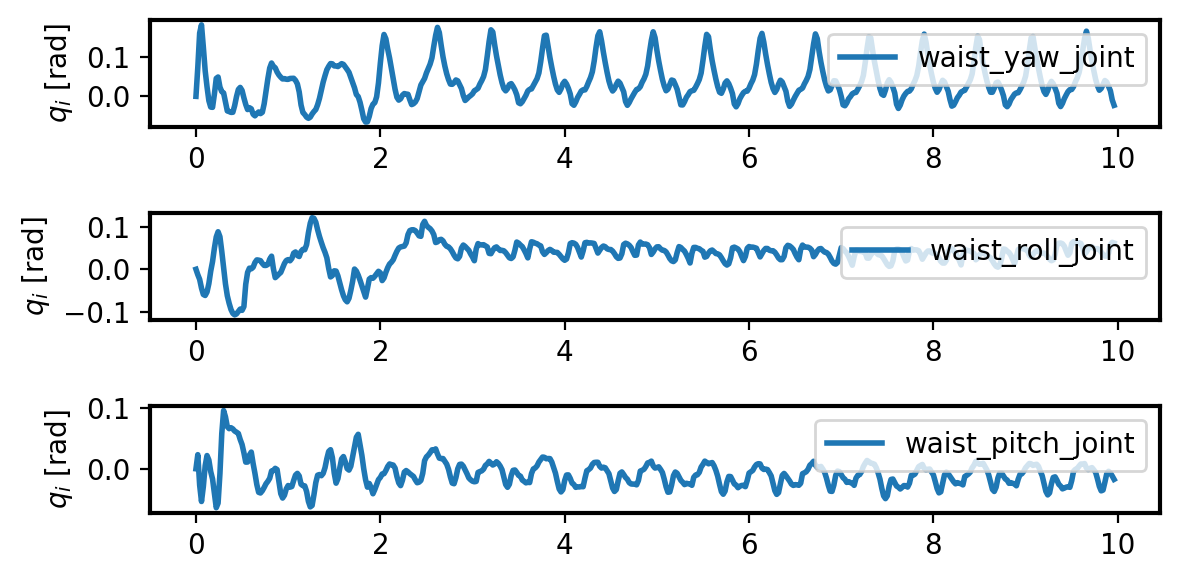

In [ ]:
ENV_ID = np.random.randint(0, data["base_lin_vel"].shape[0])
t = 1/50 * np.arange(0, 1000)
t_range = slice(0, 499)
colors = ["#1B438D", "#3C7FFD", "#BD1A1A"]


fig, axs = plt.subplots(3, 1, figsize=(6, 3))
joint_names = [
    "waist_yaw_joint", 
    "waist_roll_joint", 
    "waist_pitch_joint", 
]

# vx
for i in range(len(joint_names)):
    ax = axs[i]
    ax.plot(t[t_range], data["joint_pos"][ENV_ID, t_range, i], label=joint_names[i])
    ax.legend(loc="upper right")
    ax.set_ylabel(r'$q_i$ [rad]')


fig.tight_layout()
plt.show()

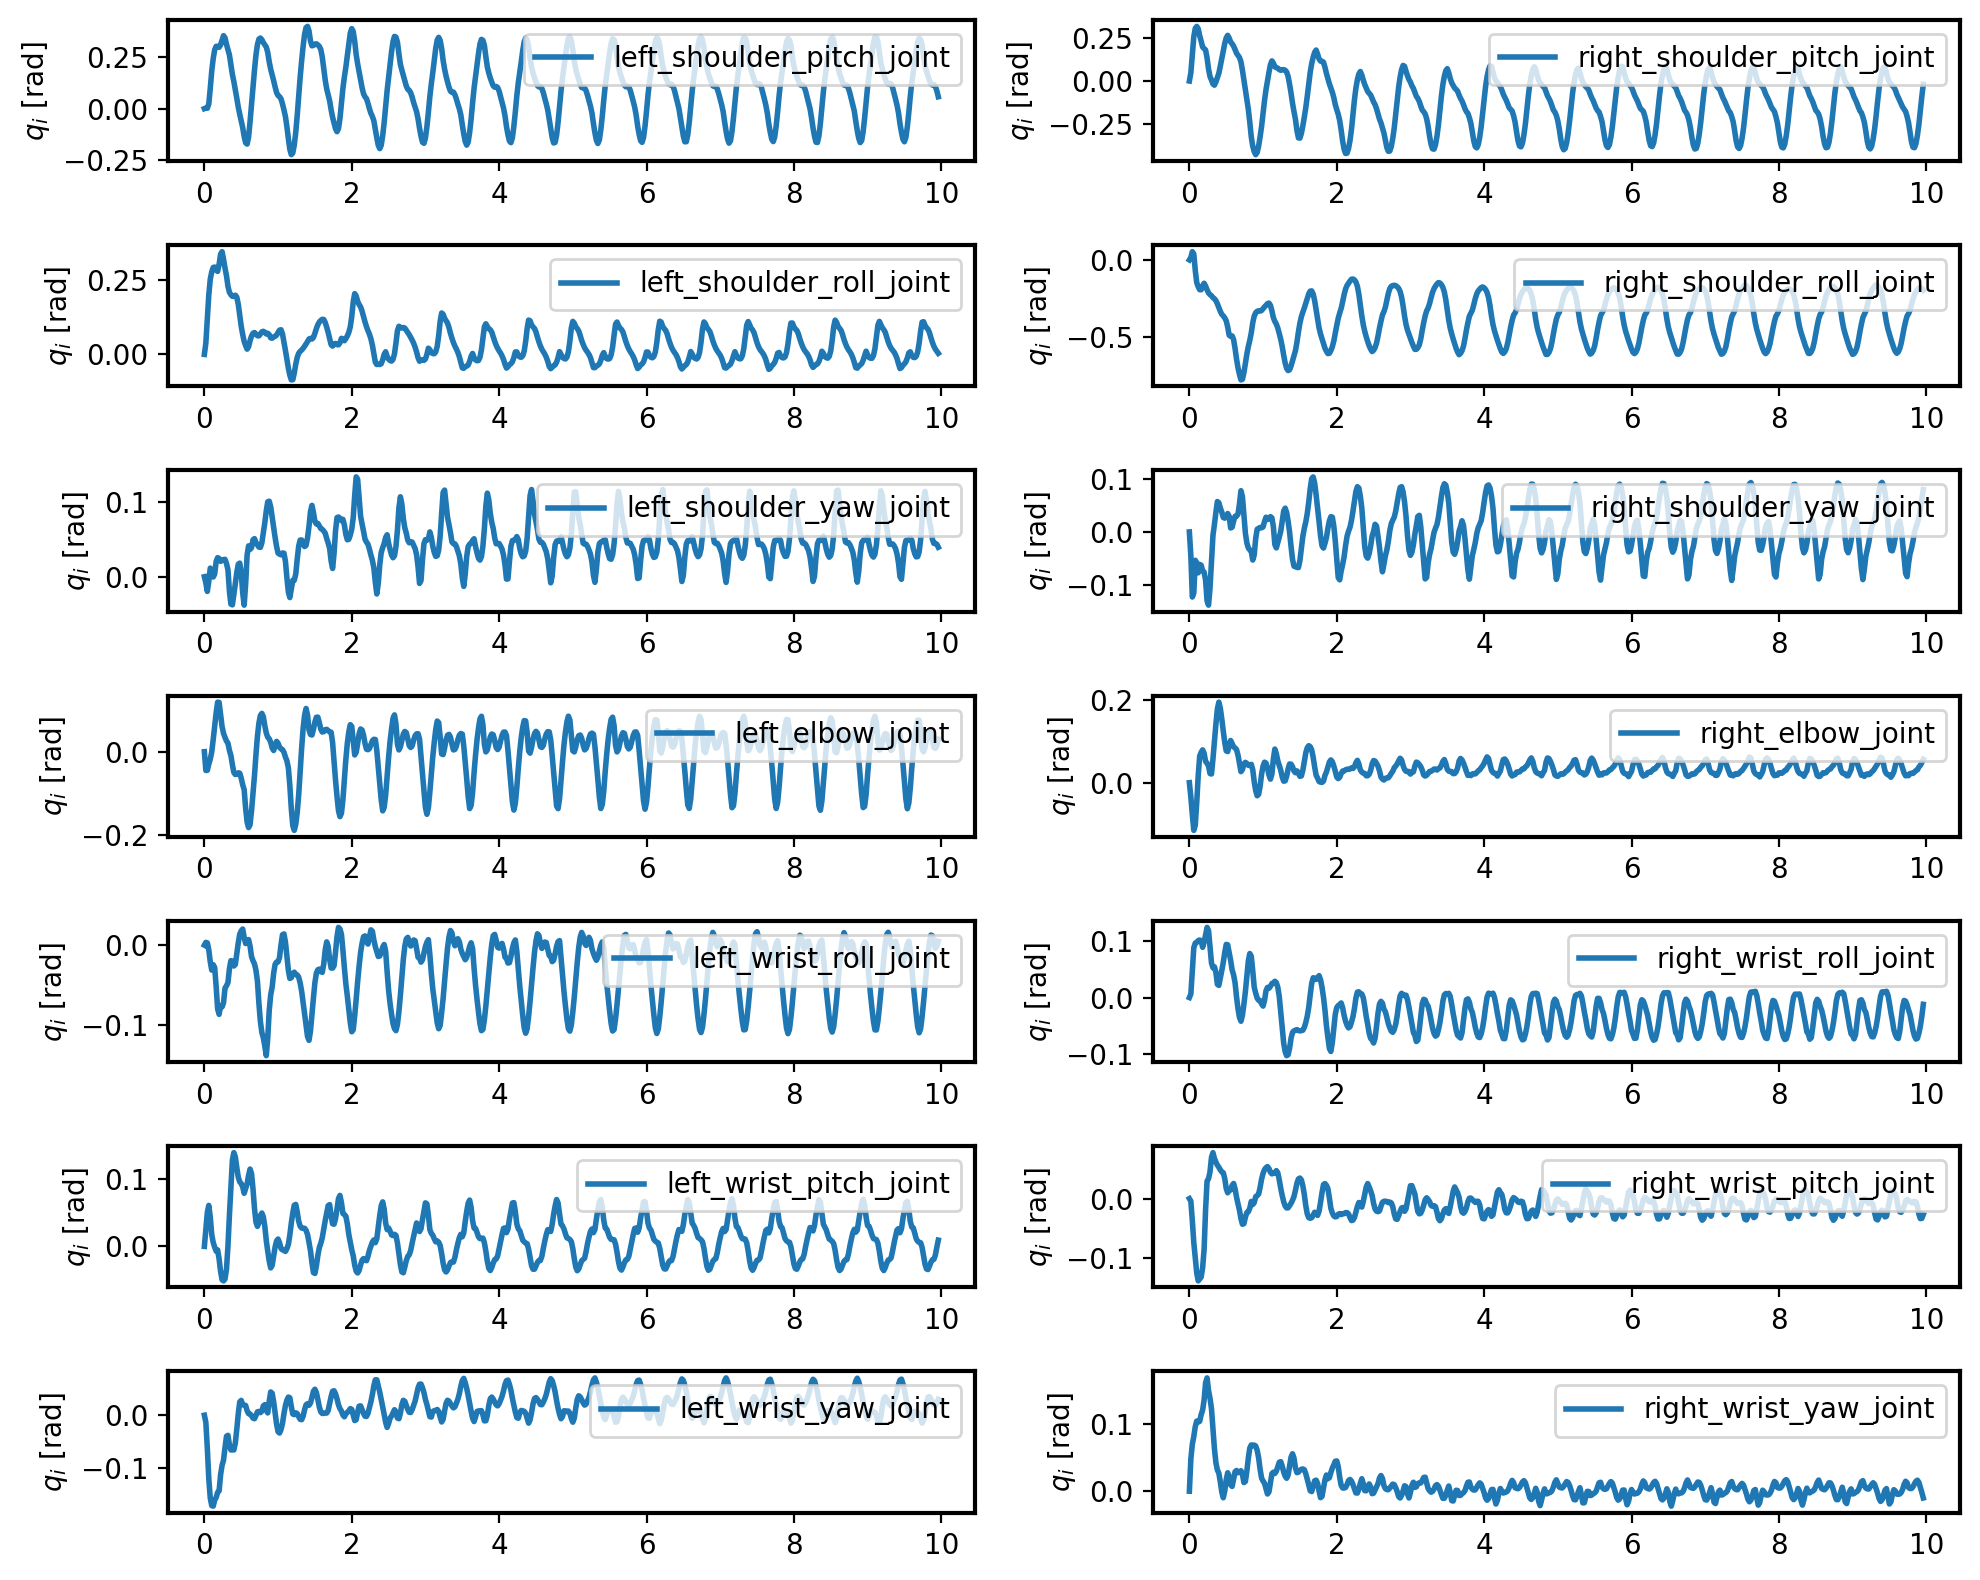

In [ ]:
ENV_ID = np.random.randint(0, data["base_lin_vel"].shape[0])
t = 1/50 * np.arange(0, 1000)
t_range = slice(0, 499)
colors = ["#1B438D", "#3C7FFD", "#BD1A1A"]


fig, axs = plt.subplots(7, 2, figsize=(10, 8))
joint_names = [
    # left arm
    "left_shoulder_pitch_joint", 
    "left_shoulder_roll_joint", 
    "left_shoulder_yaw_joint", 
    "left_elbow_joint", 

    "left_wrist_roll_joint", 
    "left_wrist_pitch_joint", 
    "left_wrist_yaw_joint", 

    # right arm
    "right_shoulder_pitch_joint", 
    "right_shoulder_roll_joint", 
    "right_shoulder_yaw_joint", 
    "right_elbow_joint", 

    "right_wrist_roll_joint", 
    "right_wrist_pitch_joint", 
    "right_wrist_yaw_joint", 
]

# vx
for i in range(len(joint_names)):
    if i < 7:
        ax = axs[i, 0]
    else:
        ax = axs[i - 7, 1]
    ax.plot(t[t_range], data["joint_pos"][ENV_ID, t_range, i+3], label=joint_names[i])
    ax.legend(loc="upper right")
    ax.set_ylabel(r'$q_i$ [rad]')


fig.tight_layout()
plt.show()

### command tracking

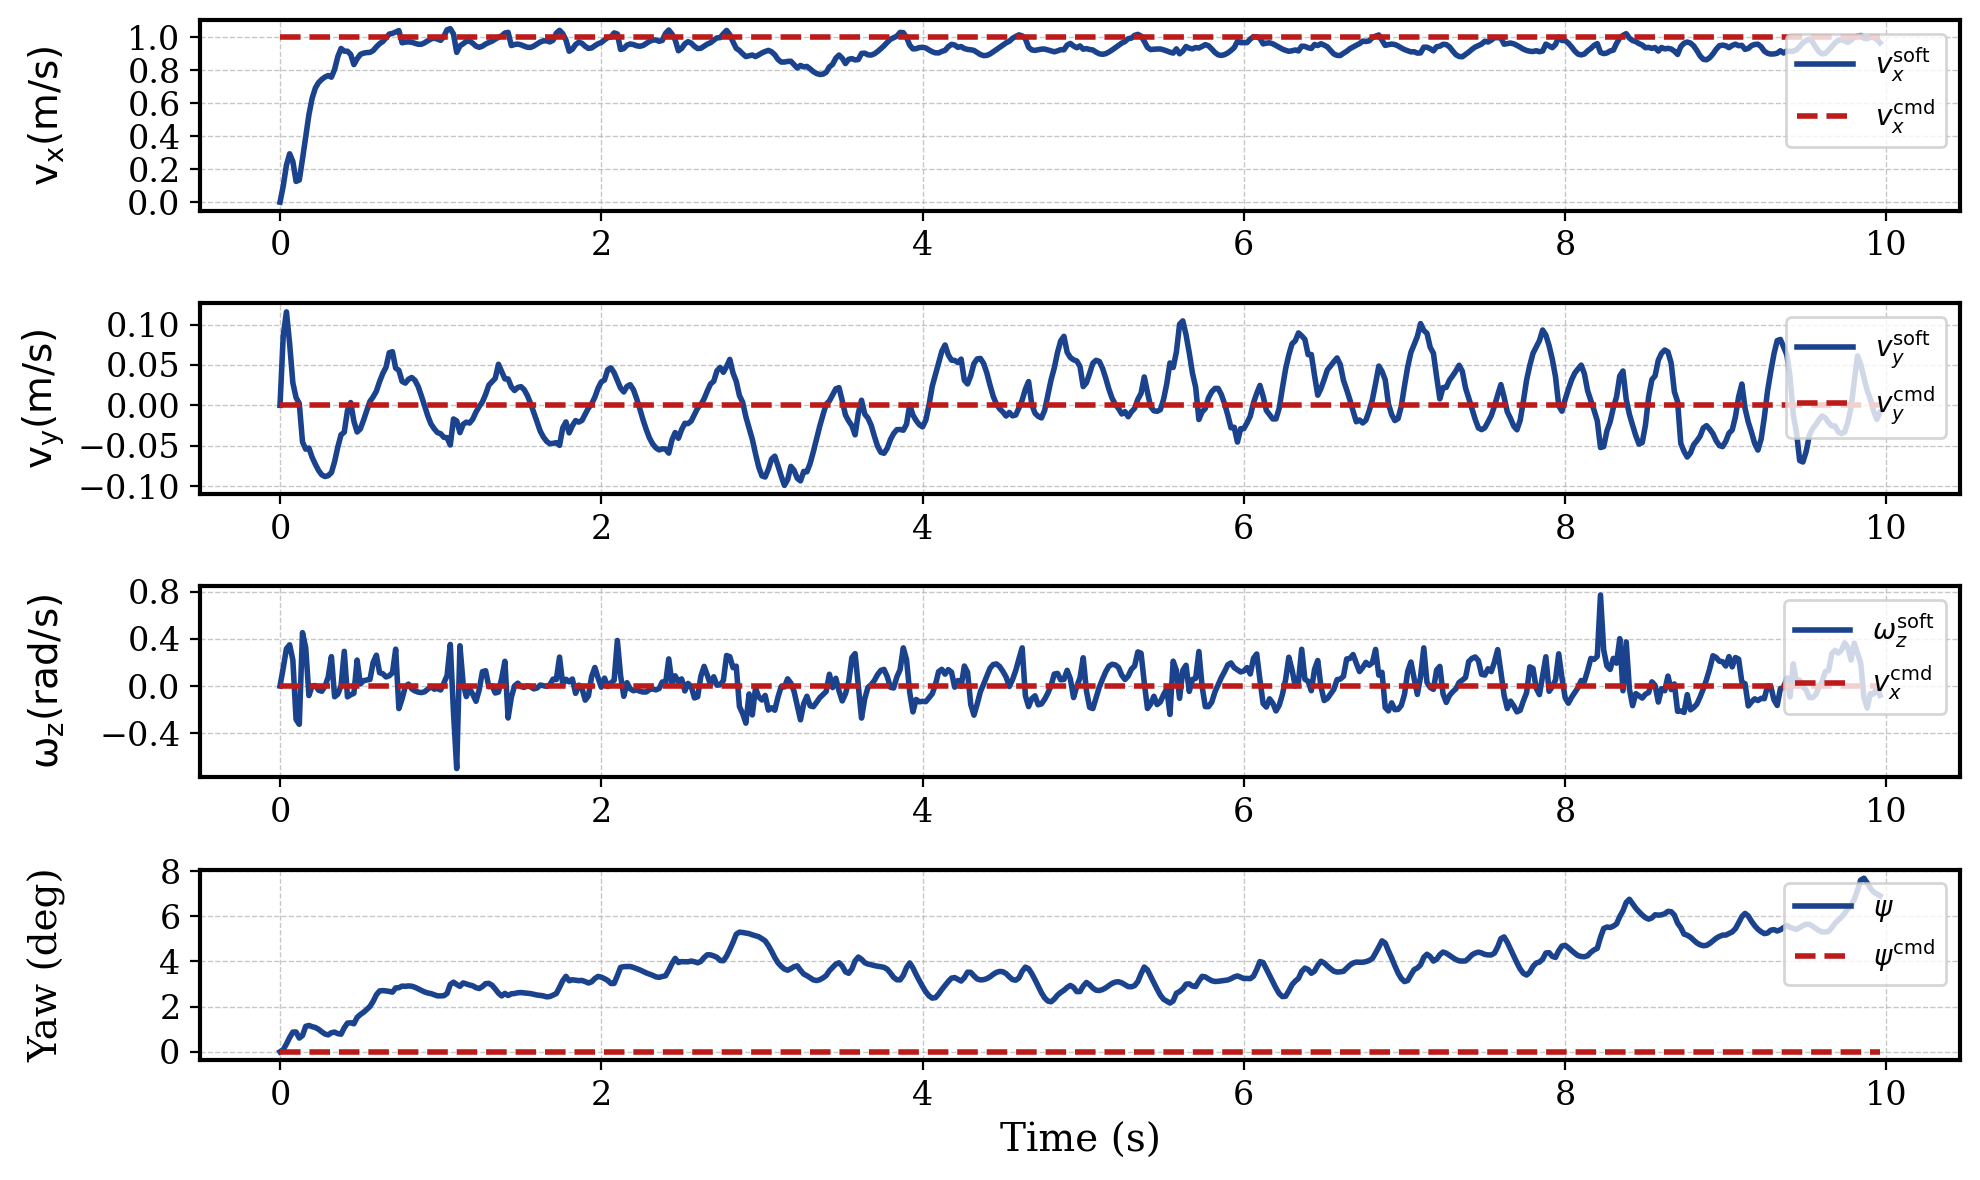

In [119]:
ENV_ID = np.random.randint(0, data["base_lin_vel"].shape[0])
t = 1/50 * np.arange(0, 1000)
t_range = slice(0, 499)
colors = ["#1B438D", "#3C7FFD", "#BD1A1A"]


fig, axs = plt.subplots(4, 1, figsize=(10, 6))

# vx
ax = axs[0]
ax.plot(t[t_range], data["base_lin_vel"][ENV_ID, t_range, 0], label=r"$v_x^\text{soft}$", color=colors[0])
# ax.plot(t[t_range], hard_contact_data["base_lin_vel"][ENV_ID, t_range, 0], label=r"$v_x^\text{hard}$", color=colors[1])
# axs.plot(t[t_range], hard_contact_data["velocity_commands"][ENV_ID, t_range, 0], '--', label=r"$v_x^\text{cmd}$", color="#126D1E")
ax.plot(t[t_range], data["velocity_commands"][ENV_ID, t_range, 0], '--', label=r"$v_x^\text{cmd}$", color=colors[2])
ax.legend(loc="upper right")
# ax.set_xlabel("Time (s)")
ax.set_ylabel(r"$\mathrm{v_x} (\mathrm{m/s})$")
ax.yaxis.set_major_locator(plt.MaxNLocator(6))
ax.grid(True, which='both', linestyle='--', linewidth=0.5, alpha=0.7)


# vy
ax = axs[1]
ax.plot(t[t_range], data["base_lin_vel"][ENV_ID, t_range, 1], label=r"$v_y^\text{soft}$", color=colors[0])
ax.plot(t[t_range], data["velocity_commands"][ENV_ID, t_range, 1], '--', label=r"$v_y^\text{cmd}$", color=colors[2])
# axs.plot(t[t_range], hard_contact_data["base_lin_vel"][ENV_ID, t_range, 1], label=r"$v_y^\text{hard}$", color=colors[0])
# axs.plot(t[t_range], hard_contact_data["velocity_commands"][ENV_ID, t_range, 1], '--', label=r"$v_y^\text{cmd}$", color="#126D1E")
ax.legend(loc="upper right")
# ax.set_xlabel("Time (s)")
ax.set_ylabel(r"$\mathrm{v_y} (\mathrm{m/s})$")
ax.yaxis.set_major_locator(plt.MaxNLocator(5))
ax.grid(True, which='both', linestyle='--', linewidth=0.5, alpha=0.7)

# wz
ax = axs[2]
ax.plot(t[t_range], data["base_ang_vel"][ENV_ID, t_range, 2], label=r"$\omega_z^\text{soft}$", color=colors[0])
ax.plot(t[t_range], data["velocity_commands"][ENV_ID, t_range, 2], '--', label=r"$v_x^\text{cmd}$", color=colors[2])
# ax.plot(t[t_range], hard_contact_data["base_ang_vel"][ENV_ID, t_range, 2], label=r"$\omega_z^\text{hard}$", color=colors[1])
# ax.plot(t[t_range], hard_contact_data["velocity_commands"][ENV_ID, t_range, 2], '--', label=r"$\omega_z^\text{cmd}$", color="#126D1E")
ax.legend(loc="upper right")
# ax.set_xlabel("Time (s)")
ax.set_ylabel(r"$\mathrm{\omega_z} (\mathrm{rad/s})$")
ax.yaxis.set_major_locator(plt.MaxNLocator(5))
ax.grid(True, which='both', linestyle='--', linewidth=0.5, alpha=0.7)

# heading 
ax = axs[3]
heading_yaw = quat_to_yaw(data["yaw_quat"][ENV_ID, t_range])
heading_cmd_yaw = quat_to_yaw(data["heading_commands"][ENV_ID, t_range])
ax.plot(t[t_range], 180/np.pi * np.unwrap(heading_yaw), label=r"$\psi$", color=colors[0])
ax.plot(t[t_range], 180/np.pi * np.unwrap(heading_cmd_yaw), '--', label=r"$\psi^\text{cmd}$", color=colors[2])
ax.legend(loc="upper right")
ax.set_xlabel("Time (s)")
ax.set_ylabel(r"Yaw (deg)")
ax.yaxis.set_major_locator(plt.MaxNLocator(5))
ax.grid(True, which='both', linestyle='--', linewidth=0.5, alpha=0.7)

fig.align_ylabels(axs)
fig.tight_layout()
# plt.savefig("g1_run_sand.pdf")
plt.show()

### velocity tracking statistical result

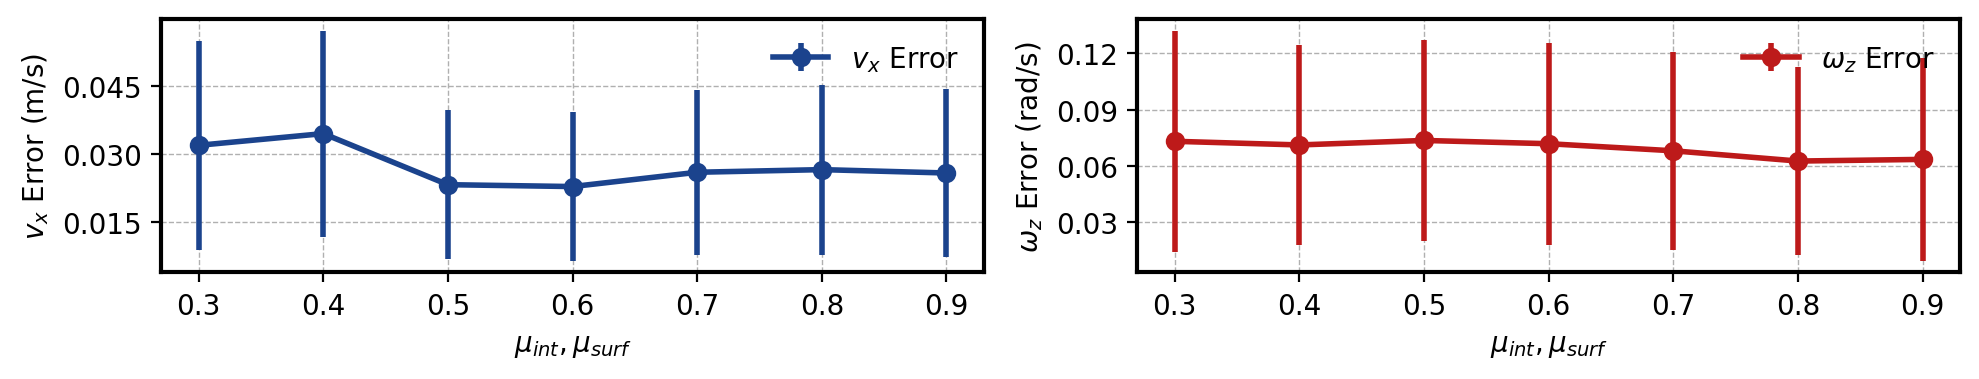

In [61]:
# error_file_path = data_dir / "g1_tracking_error.pkl"
# plot_save_path = "g1_tracking_perf.pdf"

error_file_path = data_dir / "t1_tracking_error.pkl"
plot_save_path = "t1_tracking_perf.pdf"

with open(error_file_path, "rb") as f:
    tracking_error_data = pickle.load(f)

muints = sorted(tracking_error_data.keys())
vx_err_mean = [tracking_error_data[muint]["vx"][0] for muint in muints]
vx_err_std = [tracking_error_data[muint]["vx"][1] for muint in muints]
wz_err_mean = [tracking_error_data[muint]["wz"][0] for muint in muints]
wz_err_std = [tracking_error_data[muint]["wz"][1] for muint in muints]
# mu_range = slice(None)
mu_range = slice(0, -1)

fig, ax = plt.subplots(1, 2, figsize=(10, 2))

# Plot
ax[0].errorbar(muints[mu_range], vx_err_mean[mu_range], yerr=vx_err_std[mu_range],
               fmt='-o', label=r"$v_x$ Error", color="#1B438D")
ax[1].errorbar(muints[mu_range], wz_err_mean[mu_range], yerr=wz_err_std[mu_range],
               fmt='-o', label=r"$\omega_z$ Error", color="#BD1A1A")

# === CREATE CUSTOM LABELS ===
# Convert your numeric keys to sorted floats
tick_positions = sorted(muints[mu_range])

# Build labels: last one becomes "R"
tick_labels = [f"{v:.1f}" for v in tick_positions]
# tick_labels[-1] = "R"

# Apply to both subplots
for a in ax: 
    a.set_xticks(tick_positions)
    a.set_xticklabels(tick_labels)
    a.set_xlabel("$\mu_{int}, \mu_{surf}$")
    a.yaxis.set_major_locator(plt.MaxNLocator(5))
    
ax[0].set_ylabel(r"$v_x$ Error $\mathrm{(m/s)}$")
ax[0].legend(frameon=False)
ax[0].grid(visible=True, which='both', linestyle='--', linewidth=0.5)

ax[1].set_ylabel(r"$\omega_z$ Error $\mathrm{(rad/s)}$")
ax[1].legend(frameon=False)
ax[1].grid(visible=True, which='both', linestyle='--', linewidth=0.5)

fig.tight_layout()
# plt.savefig(plot_save_path)
plt.show()
